    Key  Acute(0)/Chronic
0     1                 0
1     1                 0
2     1                 0
3     1                 0
4     1                 0
..  ...               ...
77    1                 1
78    0                 1
79    1                 1
80    1                 1
81    1                 1

[82 rows x 2 columns]
Random_state:  4
              precision    recall  f1-score   support

     healing       0.75      0.86      0.80         7
 Not-healing       0.89      0.80      0.84        10

    accuracy                           0.82        17
   macro avg       0.82      0.83      0.82        17
weighted avg       0.83      0.82      0.82        17

Accuracy: 82.35294117647058 %
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Random_state:  6
              precision    recall  f1-score   support

     healing       0.50      0.75      0.60         4
 Not-healing       0.67      0.40      0.50         5

   

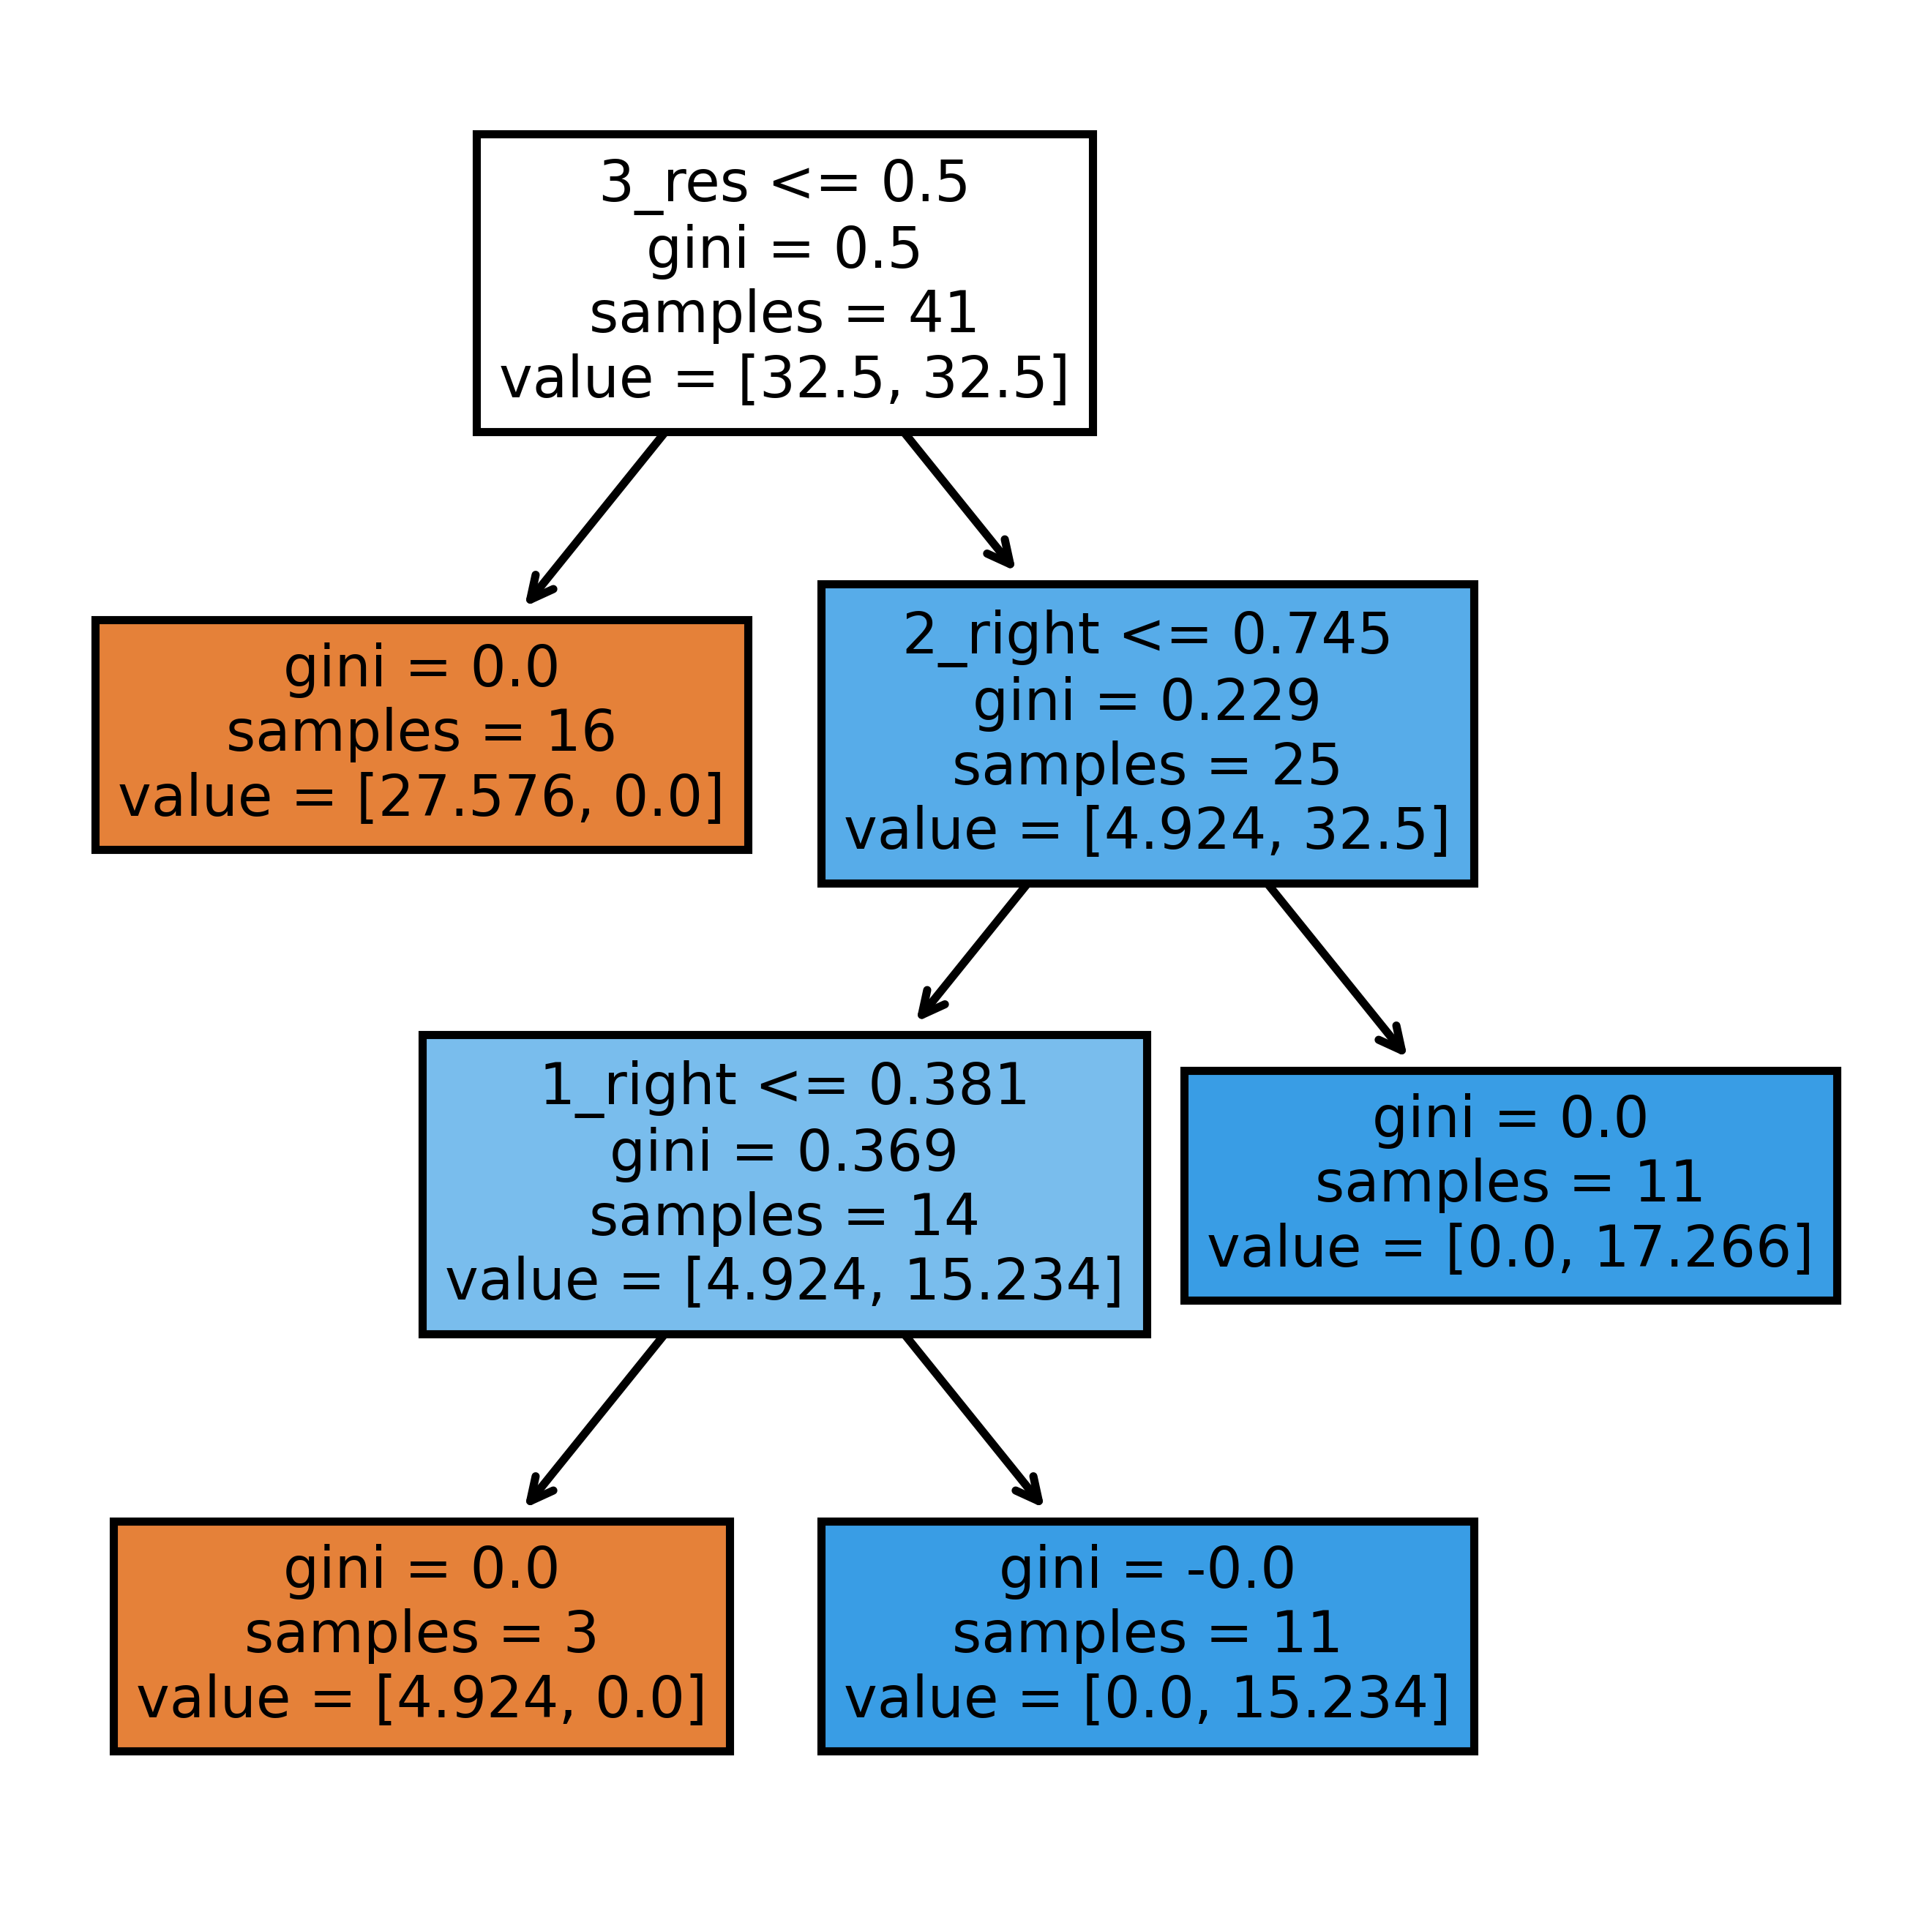

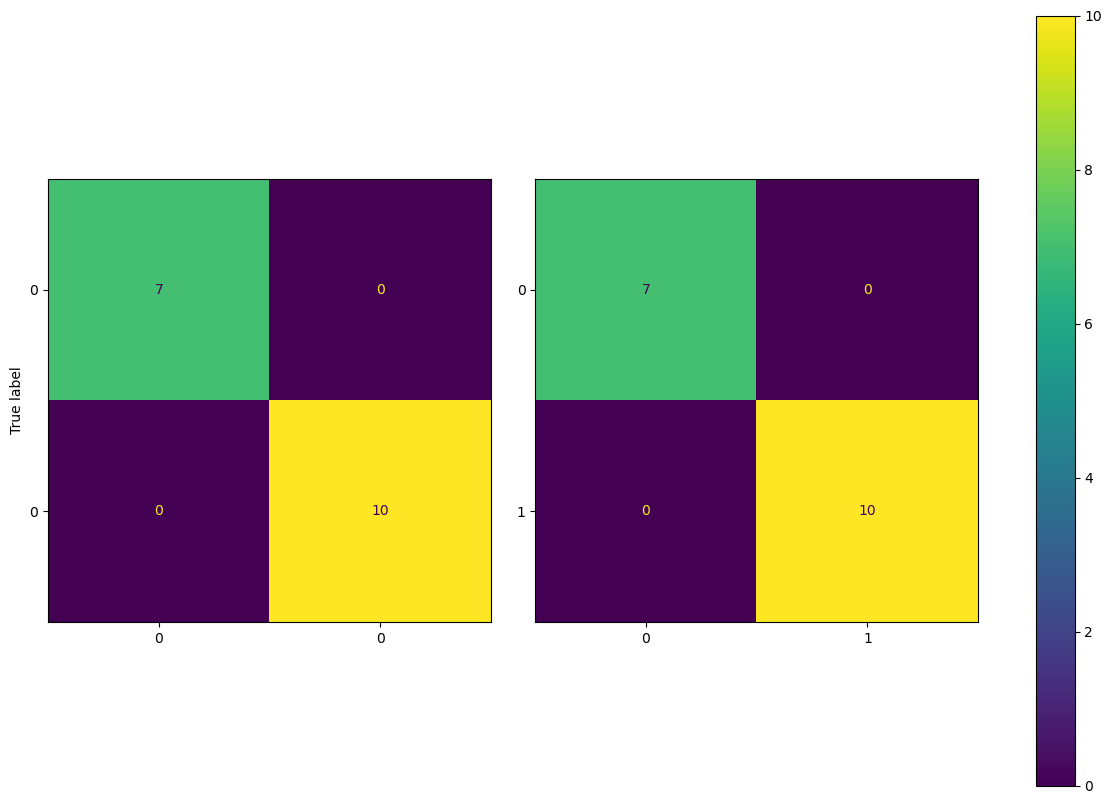

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn import tree
import matplotlib.pyplot as plt
import re
import matplotlib
import numpy as np
import pandas as pd
import xgboost as xgb
from xgboost import plot_tree
import graphviz
from xgboost import XGBRegressor
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import random
from tensorflow.keras.utils import to_categorical
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.preprocessing import StandardScaler
from mlxtend.plotting import plot_decision_regions
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
import pickle


fullinfo=False
fulltree=False



def class1_1(X_train,y_train_clf,X_test,y_test_clf):
    clf=XGBClassifier(tree_method="hist",
                      subsample=0.6,
                      colsample_bynode=0.8,
                      colsample_bylevel=0.7,
                      reg_lambda=0.6,
                      reg_alpha=0.7,
                      max_bin=2056,
                      num_parallel_tree=15,
                      eta=0.03,

    )
    if fullinfo==True:
        print("------------------------------------------Classifier 1-------------------------------")
        clf.fit(X_train, y_train_clf)
        y_pred = clf.predict(X_test)
        y_pred = (y_pred > 0.5) 
        print(classification_report(y_test_clf,y_pred,output_dict=False,target_names=["healing","Not-healing"]))
        
        if fulltree==True:
            clf.fit(X_train, y_train)
            plt.figure(figsize=(400, 120))
            plot_tree(clf)
        accuracy = accuracy_score(y_test_clf, y_pred)
        print("Accuracy:", (accuracy*100),"%")
        
    return clf

def class2_1(X_train,y_train_clf,X_test,y_test_clf):
    clf=XGBClassifier(tree_method="hist",
                      max_bin=2056,
                      num_parallel_tree=15,
                      eta=0.03,
                      reg_lambda=0.6,
                      reg_alpha=0.7,
                      objective="reg:pseudohubererror"
    )
    if fullinfo==True:
        print("------------------------------------------Classifier 2-------------------------------")
        clf.fit(X_train, y_train_clf)
        y_pred = clf.predict(X_test)
        y_pred = (y_pred > 0.5) 
        print(classification_report(y_test_clf,y_pred,output_dict=False,target_names=["healing","Not-healing"]))
    
        if fulltree==True:
            clf.fit(X_train, y_train)
            plt.figure(figsize=(400, 120))
            plot_tree(clf)
        accuracy = accuracy_score(y_test_clf, y_pred)
        print("Accuracy:", (accuracy*100),"%")
        
    return clf

def class3_1(X_train,y_train_clf,X_test,y_test_clf):
    clf=XGBClassifier(tree_method="approx",
                  eta=0.02,
                  subsample=0.5,
                 
                   objective="reg:pseudohubererror",
                   max_bin=2056,
                    reg_alpha=0.8,
                 reg_lambda=0.8,
    )
    if fullinfo==True:
        print("------------------------------------------Classifier 3-------------------------------")
        clf.fit(X_train, y_train_clf)
        y_pred = clf.predict(X_test)
        y_pred = (y_pred > 0.5) 
        print(classification_report(y_test_clf,y_pred,output_dict=False,target_names=["healing","Not-healing"]))
    
        if fulltree==True:
            clf.fit(X_train, y_train)
            plt.figure(figsize=(400, 120))
            plot_tree(clf)
        accuracy = accuracy_score(y_test_clf, y_pred)
        print("Accuracy:", (accuracy*100),"%")
        print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
    return clf
    

    
def VoteClass_1():
    Treatment=pd.read_csv("../dissertation/Wound area data v2.csv")
    df_x=Treatment.iloc[:,1:]
    df_y=Treatment.iloc[:,0]
    R_state=random.randrange(1,10)
    print("Random_state: ",R_state)
    R_state=14
    X_train, X_test, y_train, y_test = train_test_split(df_x, df_y, test_size=0.2, random_state=R_state,stratify=df_y)
    y_train_clf = to_categorical(y_train)
    y_test_clf = to_categorical(y_test)

    clf1=class1_1(X_train,y_train_clf,X_test,y_test_clf)
    clf2=class2_1(X_train,y_train_clf,X_test,y_test_clf)
    clf3=class3_1(X_train,y_train_clf,X_test,y_test_clf)
    sclf = VotingClassifier(estimators=[('clf1', clf1), ('clf2', clf2), ('clf3', clf3)],voting='soft',flatten_transform=False)
    
    sclf.fit(X_train, y_train)
    
    y_pred = sclf.predict(X_test)
    print(classification_report(np.asarray(y_test_clf).argmax(axis=1),y_pred,output_dict=False,target_names=["healing","Not-healing"]))
    
    accuracy = accuracy_score(np.asarray(y_test_clf).argmax(axis=1), y_pred)
    print("Accuracy:", (accuracy*100),"%")
    print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
    y_pred1 = sclf.predict_proba(df_x)
    y_pred = sclf.predict(df_x)
    return y_pred1, y_pred

    


    
    
    
    
    
    
    
    
    
    
    
    
    
    
def class1_2(X_train,y_train_clf,X_test,y_test_clf):
    clf=XGBClassifier(tree_method="hist",
                      subsample=0.6,
                      colsample_bynode=0.8,
                      colsample_bylevel=0.7,
                      reg_lambda=0.6,
                      reg_alpha=0.7,
                      max_bin=2056,
                      num_parallel_tree=15,
                      eta=0.03,

    )
    if fullinfo==True:
        print("------------------------------------------Classifier 1-------------------------------")
        clf.fit(X_train, y_train_clf)
        y_pred = clf.predict(X_test)
        y_pred = (y_pred > 0.5) 
        print(classification_report(y_test_clf,y_pred,output_dict=False,target_names=["healing","Not-healing"]))
        
        if fulltree==True:
            clf.fit(X_train, y_train)
            plt.figure(figsize=(400, 120))
            plot_tree(clf)
        accuracy = accuracy_score(y_test_clf, y_pred)
        print("Accuracy:", (accuracy*100),"%")
        
    return clf

def class2_2(X_train,y_train_clf,X_test,y_test_clf):
    clf=XGBClassifier(eta=0.01,
                      max_bin=1024,
    )
    if fullinfo==True:
        print("------------------------------------------Classifier 2-------------------------------")
        clf.fit(X_train, y_train_clf)
        y_pred = clf.predict(X_test)
        y_pred = (y_pred > 0.5) 
        print(classification_report(y_test_clf,y_pred,output_dict=False,target_names=["healing","Not-healing"]))
    
        if fulltree==True:
            clf.fit(X_train, y_train)
            plt.figure(figsize=(400, 120))
            plot_tree(clf)
        accuracy = accuracy_score(y_test_clf, y_pred)
        print("Accuracy:", (accuracy*100),"%")
        
    return clf

def class3_2(X_train,y_train_clf,X_test,y_test_clf):
    clf=XGBClassifier(tree_method="approx",
                  eta=0.02,
                  subsample=0.5,
                 
                   
                   max_bin=2056,
                    reg_alpha=0.8,
                 reg_lambda=0.8,
    )
    if fullinfo==True:
        print("------------------------------------------Classifier 3-------------------------------")
        clf.fit(X_train, y_train_clf)
        y_pred = clf.predict(X_test)
        y_pred = (y_pred > 0.5) 
        print(classification_report(y_test_clf,y_pred,output_dict=False,target_names=["healing","Not-healing"]))
    
        if fulltree==True:
            clf.fit(X_train, y_train)
            plt.figure(figsize=(400, 120))
            plot_tree(clf)
        accuracy = accuracy_score(y_test_clf, y_pred)
        print("Accuracy:", (accuracy*100),"%")
        print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
    return clf
    

    
def VoteClass_2():
    Treatment=pd.read_csv("../dissertation/Wound area v2.csv")
    df_x=Treatment.iloc[:,1:]
    df_y=Treatment.iloc[:,0]
    R_state=random.randrange(1,10)
    print("Random_state: ",R_state)
    R_state=18
    X_train, X_test, y_train, y_test = train_test_split(df_x, df_y, test_size=0.1, random_state=R_state,stratify=df_y)

    y_train_clf = to_categorical(y_train)
    y_test_clf = to_categorical(y_test)

    clf1=class1_2(X_train,y_train_clf,X_test,y_test_clf)
    clf2=class2_2(X_train,y_train_clf,X_test,y_test_clf)
    clf3=class3_2(X_train,y_train_clf,X_test,y_test_clf)
    sclf = VotingClassifier(estimators=[('clf1', clf1), ('clf2', clf2), ('clf3', clf3)],voting='soft',flatten_transform=False)
    
    sclf.fit(X_train, y_train)
    
    y_pred = sclf.predict(X_test)
    print(classification_report(np.asarray(y_test_clf).argmax(axis=1),y_pred,output_dict=False,target_names=["healing","Not-healing"]))
    
    accuracy = accuracy_score(np.asarray(y_test_clf).argmax(axis=1), y_pred)
    print("Accuracy:", (accuracy*100),"%")
    print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
    y_pred1 = sclf.predict_proba(df_x)
    y_pred = sclf.predict(df_x)
    return y_pred1, y_pred










def class1_3(X_train,y_train_clf,X_test,y_test_clf):
    clf=XGBClassifier(tree_method="hist",
                colsample_bynode=0.5,
                    colsample_bylevel=0.5,
                  colsample_bytree=0.8,
                    subsample=0.6,
                   # min_child_weight=0.2,
                    objective="reg:pseudohubererror",
                    max_bin=2056,
                     eta=0.01,
                  reg_alpha=0.8,
                  reg_lambda=0.07,
                      #grow_policy='lossguide',
                      num_parallel_tree=20,

    )
    if fullinfo==True:
        print("------------------------------------------Classifier 1-------------------------------")
        clf.fit(X_train, y_train_clf)
        y_pred = clf.predict(X_test)
        y_pred = (y_pred > 0.5) 
        print(classification_report(y_test_clf,y_pred,output_dict=False,target_names=["healing","Not-healing"]))
        
        if fulltree==True:
            clf.fit(X_train, y_train)
            plt.figure(figsize=(400, 120))
            plot_tree(clf)
        accuracy = accuracy_score(y_test_clf, y_pred)
        print("Accuracy:", (accuracy*100),"%")
        
    return clf

def class2_3(X_train,y_train_clf,X_test,y_test_clf):
    clf=XGBClassifier(eta=0.01,
                      subsample=0.5,
                      tree_method="approx"
    )
    if fullinfo==True:
        print("------------------------------------------Classifier 2-------------------------------")
        clf.fit(X_train, y_train_clf)
        y_pred = clf.predict(X_test)
        y_pred = (y_pred > 0.5) 
        print(classification_report(y_test_clf,y_pred,output_dict=False,target_names=["healing","Not-healing"]))
    
        if fulltree==True:
            clf.fit(X_train, y_train)
            plt.figure(figsize=(400, 120))
            plot_tree(clf)
        accuracy = accuracy_score(y_test_clf, y_pred)
        print("Accuracy:", (accuracy*100),"%")
        
    return clf

def class3_3(X_train,y_train_clf,X_test,y_test_clf):
    clf=XGBClassifier(#tree_method="exact",
                  eta=0.02,
                  subsample=0.5,
                 
                   objective="reg:pseudohubererror",
                   max_bin=2056,
                    reg_alpha=0.6,
                 reg_lambda=0.4,
    )
    if fullinfo==True:
        print("------------------------------------------Classifier 3-------------------------------")
        clf.fit(X_train, y_train_clf)
        y_pred = clf.predict(X_test)
        y_pred = (y_pred > 0.5) 
        print(classification_report(y_test_clf,y_pred,output_dict=False,target_names=["healing","Not-healing"]))
    
        if fulltree==True:
            clf.fit(X_train, y_train)
            plt.figure(figsize=(400, 120))
            plot_tree(clf)
        accuracy = accuracy_score(y_test_clf, y_pred)
        print("Accuracy:", (accuracy*100),"%")
        print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
    return clf
    

    
def VoteClass_3():
    Treatment=pd.read_csv("../dissertation/Wound area exit v2.csv")
    df_x=Treatment.iloc[:,1:]
    df_y=Treatment.iloc[:,0]
    R_state=random.randrange(1,10)
    print("Random_state: ",R_state)
    R_state=5
    X_train, X_test, y_train, y_test = train_test_split(df_x, df_y, test_size=0.15, random_state=R_state,stratify=df_y)

    y_train_clf = to_categorical(y_train)
    y_test_clf = to_categorical(y_test)

    clf1=class1_2(X_train,y_train_clf,X_test,y_test_clf)
    clf2=class2_2(X_train,y_train_clf,X_test,y_test_clf)
    clf3=class3_2(X_train,y_train_clf,X_test,y_test_clf)
    sclf = VotingClassifier(estimators=[('clf1', clf1), ('clf2', clf2), ('clf3', clf3)],voting='soft',flatten_transform=False)
    
    sclf.fit(X_train, y_train)
    
    y_pred = sclf.predict(X_test)
    print(classification_report(np.asarray(y_test_clf).argmax(axis=1),y_pred,output_dict=False,target_names=["healing","Not-healing"]))
    
    accuracy = accuracy_score(np.asarray(y_test_clf).argmax(axis=1), y_pred)
    print("Accuracy:", (accuracy*100),"%")
    print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
    y_pred1 = sclf.predict_proba(df_x)
    y_pred = sclf.predict(df_x)
    return y_pred1, y_pred



#------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
    
def combinetogether():
    Treatment=pd.read_csv("../dissertation/combine.csv")
    print(Treatment)
    new_data, n_data=VoteClass_1()  
    new_data=pd.DataFrame(new_data)
    n_data=pd.DataFrame(n_data)
    dat1 = pd.concat([Treatment, new_data], axis=1)
    dat1 = pd.concat([dat1, n_data], axis=1)
    
    new_data, n_data=VoteClass_2()  
    new_data=pd.DataFrame(new_data)
    n_data=pd.DataFrame(n_data)
    dat1 = pd.concat([dat1, new_data], axis=1)
    dat1 = pd.concat([dat1, n_data], axis=1)
    
    
    new_data, n_data=VoteClass_3()  
    new_data=pd.DataFrame(new_data)
    n_data=pd.DataFrame(n_data)
    dat1 = pd.concat([dat1, new_data], axis=1)
    dat1 = pd.concat([dat1, n_data], axis=1)
    dat1.columns = ["ID","Acute(0)/Chronic", "1_left", "1_right","1_res","2_left", "2_right","2_res","3_left", "3_right","3_res"]
    #print(dat1)
    

    
    df_x=dat1.iloc[:,1:]
    df_y=dat1.iloc[:,0]
    R_state=random.randrange(1,25)
    print("Random_state: ",R_state)
    R_state=19
    X_train, X_test, y_train, y_test = train_test_split(df_x, df_y, test_size=0.2, random_state=R_state,stratify=df_y)
    
    clf = RandomForestClassifier(max_depth=None, random_state=9,oob_score=True,class_weight="balanced_subsample",n_estimators=300)
    
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    y_pred = (y_pred > 0.5) 
    print(classification_report(y_test,y_pred,output_dict=False,target_names=["healing","Not-healing"]))
    accuracy = accuracy_score(y_test, y_pred)
    print("Accuracy:", (accuracy*100),"%")
    fn=["Acute(0)/Chronic","1_left", "1_right","1_res","2_left", "2_right","2_res","3_left", "3_right","3_res"]
    fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (4,4), dpi=800)
    tree.plot_tree(clf.estimators_[0],
               feature_names = fn, 
               filled = True);
    f, axes = plt.subplots(1, 2, figsize=(15, 10))
    axes = axes.ravel()
    #goal_class=["Healing","non-healing","deterioration"]
    for i in range(2):
        disp = ConfusionMatrixDisplay(confusion_matrix(y_test,
                                                       y_pred),
                                      display_labels=[0, i])
        disp.plot(ax=axes[i], values_format='.4g')
        #disp.ax_.set_title(goal_class[i])
        if i<10:
            disp.ax_.set_xlabel('')
        if i%5!=0:
            disp.ax_.set_ylabel('')
        disp.im_.colorbar.remove()

    plt.subplots_adjust(wspace=0.10, hspace=0.1)
    f.colorbar(disp.im_, ax=axes)
    plt.show()

    

    
    
combinetogether()